In [ ]:
#backward() metodunu yaz: çıktının gradient'ini 1 yap, node'ları ters topological sırayla gez, her node'da chain rule uygula. Bir değişken birden fazla yerde kullanılıyorsa gradient'leri topla, üzerine yazma. (1:09:02 - 1:27:05)

In [22]:
import math
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data   
        self.grad = 0.0    
        self._backward = lambda: None 
        self._prev = set(_children) 
        self._op = _op 
        self.label = label 

    def __repr__(self): 
        out = f"Value(data={self.data})"  
        return out 
    
    def __add__(self, other):  
        out = Value(self.data + other.data, (self, other), '+') 

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __mul__(self, other): 
        out = Value(self.data * other.data, (self, other), '*') 

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def tanh(self): 
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out
    
    def backward (self): 
        topo = [] 
        visited = set () 
        def build_topo(v): 
            if v not in visited:  #ziyaret edilmemiş nodlarda 
                visited.add(v) #ziyaret edilenlere eklenir 
                for child in v._prev: build_topo(child) # önce onların çocukları gezilerek  
                topo.append(v) # en sonda ise ebebeyn eklenir 
        build_topo(self) 
        self.grad = 1.0   #mannuel girdiğimiz o.grad = 1.0 ı burada tanımlıyoruz
        for node in reversed (topo): # burada listenin sonunda olan 'o' aslında backwardı doğru sırada çalıştırmamız için reversed ile listenin başına alıyor.
            node._backward()


In [5]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record') 
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

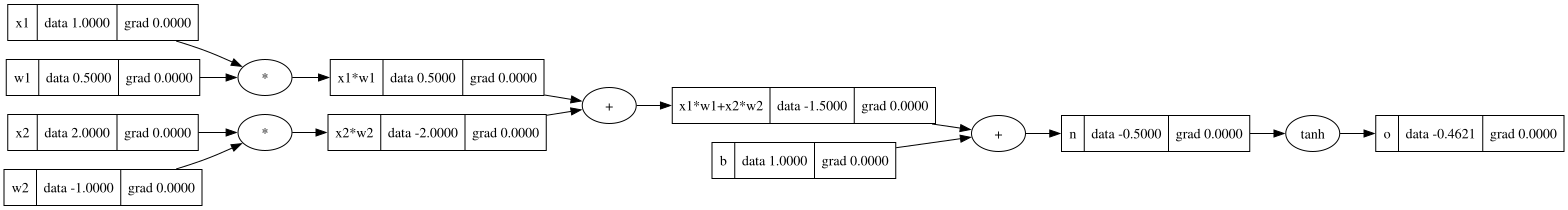

In [6]:
x1 = Value(1.0 , label = 'x1')
x2 = Value(2.0, label = 'x2')

w1 = Value(0.5, label = 'w1')
w2 = Value(-1.0 , label = 'w2')

b = Value(1.0 , label  = 'b' ) 

#1 nöron n = x1*w1 + x2 * w2 + b 

x1w1 = x1*w1 ;  x1w1.label = 'x1*w1'
x2w2 = x2*w2 ; x2w2.label  ='x2*w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1*w1+x2*w2'

n = x1w1x2w2 + b ; n.label = 'n'

o = n.tanh(); o.label = 'o' 
draw_dot(o)

In [7]:
#do / do = 1.0
o.grad = 1.0 

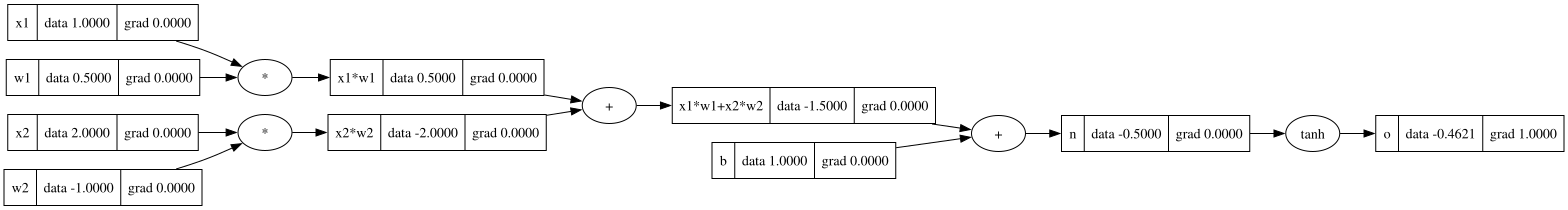

In [8]:
draw_dot(o)

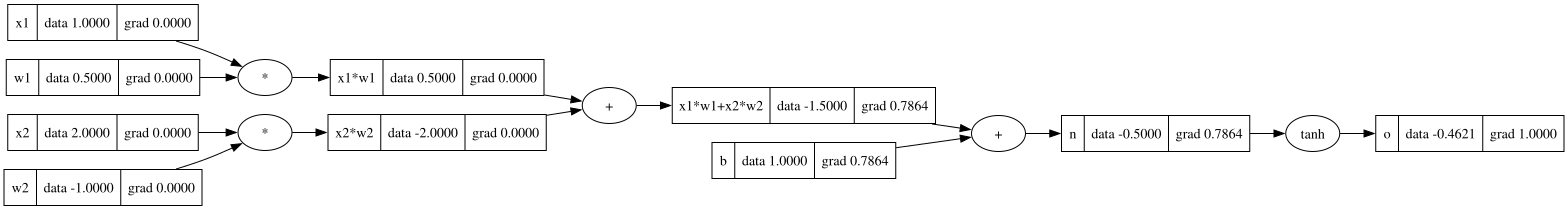

In [ ]:
# n.grad = (1-o.grad**2)
o._backward()
n._backward()
draw_dot(o)

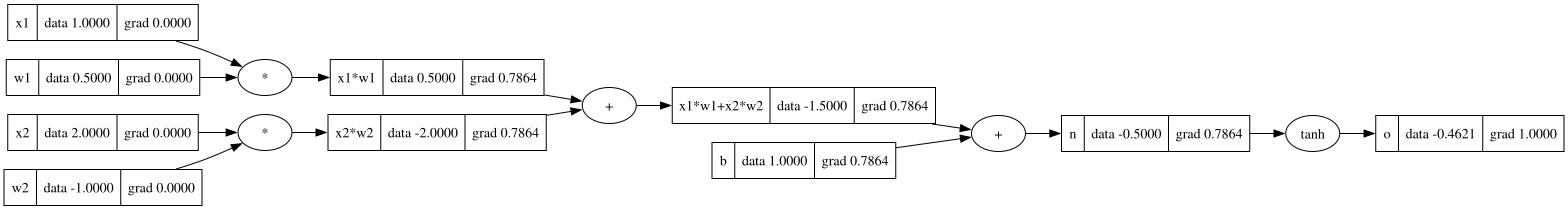

In [14]:
x1w1x2w2._backward()
b._backward()
draw_dot(o)

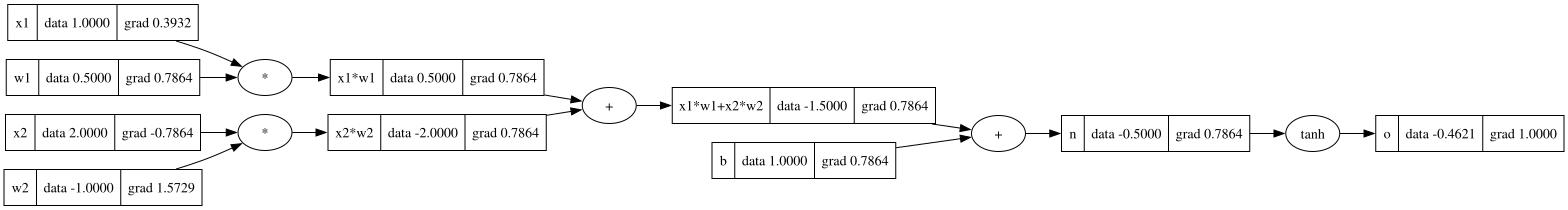

In [15]:
x1w1._backward()
x2w2._backward()
draw_dot(o)
#x1w1 in çocukları x1 , w1 x2w2 nin çocukları x2 , w2 , x1w1._backward() çağırarak çocukları beslemiş oluyoruz. 

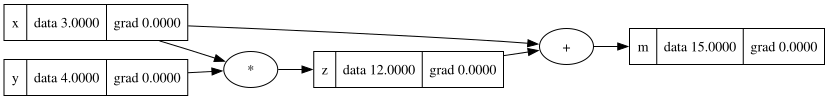

In [19]:
#yeni oluşturduğumuz backward fonksiyonunu ile yeni bir örnek yapalım ancak bu örneği 2 tane aynı değişken kullanılarak yapalım ki hem de value sınıfına += eklememiz gerektiğini öğrenelim.
x = Value(3.0, label='x')
y = Value(4.0, label='y')

z = x * y;      z.label = 'z'     
m = x + z;      m.label = 'm'
draw_dot(m)

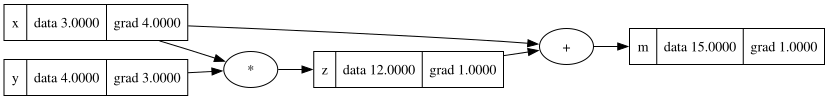

In [21]:
m.grad = 1.0
m.backward()
draw_dot(m)

In [ ]:
#yıkarıdakileri elle hesapladığımızda 
# m.grad = 1.0
# m = x + z  bu da dm / dx  = 1    dm / dz = 1    
# z = x * y bu da dz / dx = y yani y.data dz / dy = x yani x.data
#x.grad burada toplamadan 1 + çarpmadan da ynin datası yani 4 alır bu ikisinin toplamı 5 olur yani x.grad = 5 ancak burada += yapmadığımız için 4 gelmiş 
#z.grad dm / dz = 1 
#y.grad dz / dy = xdata  = 3 

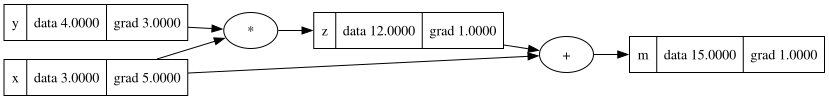

In [23]:
# += yaptıktan sonra 
x = Value(3.0, label='x')
y = Value(4.0, label='y')

z = x * y;      z.label = 'z'     
m = x + z;      m.label = 'm'

m.backward()
draw_dot(m)
